<a href="https://colab.research.google.com/github/mrunmayee3108/SciExpert/blob/main/SciQ_clean_preprocess_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from datasets import load_dataset
import pandas as pd
import random

In [2]:
dataset = load_dataset("allenai/sciq", split = "train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.02k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/339k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11679 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [11]:
df = pd.DataFrame(dataset)
print("Original rows:", len(df))

Original rows: 11679


In [4]:
df = df.drop_duplicates(subset=["question"])

In [12]:
len(df)  # 70 duplicate questions dropped.

11679

In [13]:
df = df.dropna(subset=["question","correct_answer","distractor1","distractor2","distractor3"])

In [14]:
import re

In [15]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
for col in ["question","correct_answer","distractor1","distractor2","distractor3"]:
    df[col] = df[col].apply(clean_text)

In [16]:
df.head()

,question,distractor3,distractor1,distractor2,correct_answer,support
0,What type of organism is commonly used in prep...,viruses,protozoa,gymnosperms,mesophilic organisms,"Mesophiles grow best in moderate temperature, ..."
1,What phenomenon makes global winds blow northe...,tropical effect,muon effect,centrifugal effect,coriolis effect,Without Coriolis Effect the global winds would...
2,Changes from a less-ordered state to a more-or...,endothermic,unbalanced,reactive,exothermic,Summary Changes of state are examples of phase...
3,What is the least dangerous radioactive decay?,zeta decay,beta decay,gamma decay,alpha decay,All radioactive decay is dangerous to living t...
4,Kilauea in hawaii is the world’s most continuo...,magma,greenhouse gases,carbon and smog,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...


In [17]:
final_rows = []
for _, row in df.iterrows():
  options = [
      row['correct_answer'],
      row['distractor1'],
      row['distractor2'],
      row['distractor3']
  ]
  random.shuffle(options)
  answer_index = options.index(row["correct_answer"])
  answer_key = "ABCD"[answer_index]
  final_rows.append({
      "dataset_source": "SciQ",
      "text":f"Question: {row['question']}\n\n" f"A. {options[0]}\n" f"B. {options[1]}\n" f"C. {options[2]}\n" f"D. {options[3]}\n\n" f"Answer: {answer_key}",
      "answer_key": answer_key
  })
  clean_df = pd.DataFrame(final_rows)

In [18]:
clean_df.head()

,dataset_source,text,answer_key
0,SciQ,Question: What type of organism is commonly us...,D
1,SciQ,Question: What phenomenon makes global winds b...,A
2,SciQ,Question: Changes from a less-ordered state to...,D
3,SciQ,Question: What is the least dangerous radioact...,C
4,SciQ,Question: Kilauea in hawaii is the world’s mos...,C


In [19]:
clean_df.to_csv("sciq_clean.csv",index=False)

In [20]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11679 entries, 0 to 11678
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   dataset_source  11679 non-null  object
 1   text            11679 non-null  object
 2   answer_key      11679 non-null  object
dtypes: object(3)
memory usage: 273.9+ KB


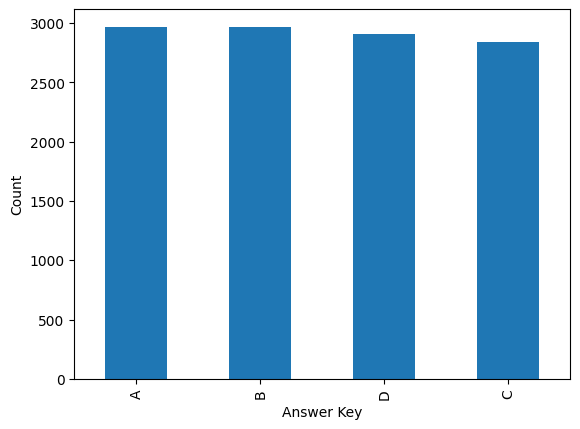

In [21]:
# ans distribution
import matplotlib.pyplot as plt
clean_df['answer_key'].value_counts().plot(kind='bar')
plt.xlabel('Answer Key')
plt.ylabel('Count')
plt.show()

- most of the answers are A, followed by C, B, D
- roughly equal counts for A/B/C/D because of shuffling.

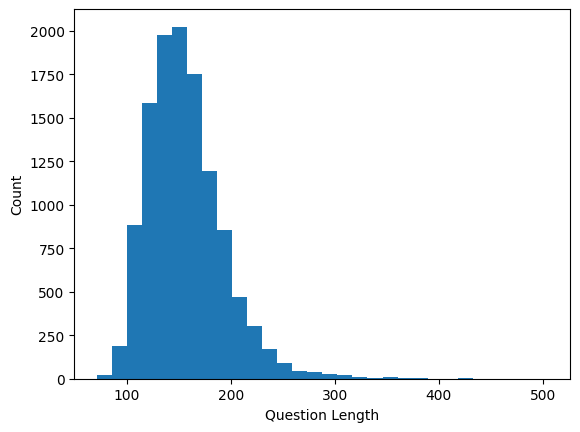

In [22]:
# ques length distribution
ques_len = clean_df['text'].str.len()
plt.hist(ques_len, bins=30)
plt.xlabel('Question Length')
plt.ylabel('Count')
plt.show()

- most of the ques are around 150 characters long.
- very few questions are larger than 350 characters.

In [23]:
ques_len.describe()

,text
count,11679.000000
mean,156.547906
std,37.159436
min,71.000000
25%,130.000000
50%,152.000000
75%,176.000000
max,505.000000


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
import json
path = "/content/drive/MyDrive/Colab Notebooks/SciQ_clean_preprocess_FIXED.ipynb"
with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)
nb.get("metadata", {}).pop("widgets", None)
for cell in nb.get("cells", []):
    cell.get("metadata", {}).pop("widgets", None)
with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)
print("Fixed notebook metadata!")

Fixed notebook metadata!
